<a href="https://colab.research.google.com/github/amallindask/data-science-2026/blob/main/Pertemuan5_Amallinda_250401020003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DASHBOARD VISUALISASI STATIS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [2]:
# 1. LOAD & INSPECT DATASET

df = sns.load_dataset('tips')
print(df.shape, df.dtypes)
print('\n',df.describe().round(2))

(244, 7) total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

        total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


In [3]:
#LOAD DATASET
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
# CEK MISSING VALUE
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


In [5]:
print(df.shape)

(244, 7)


Dashboard tersimpan sebagai dashboard_tips.png


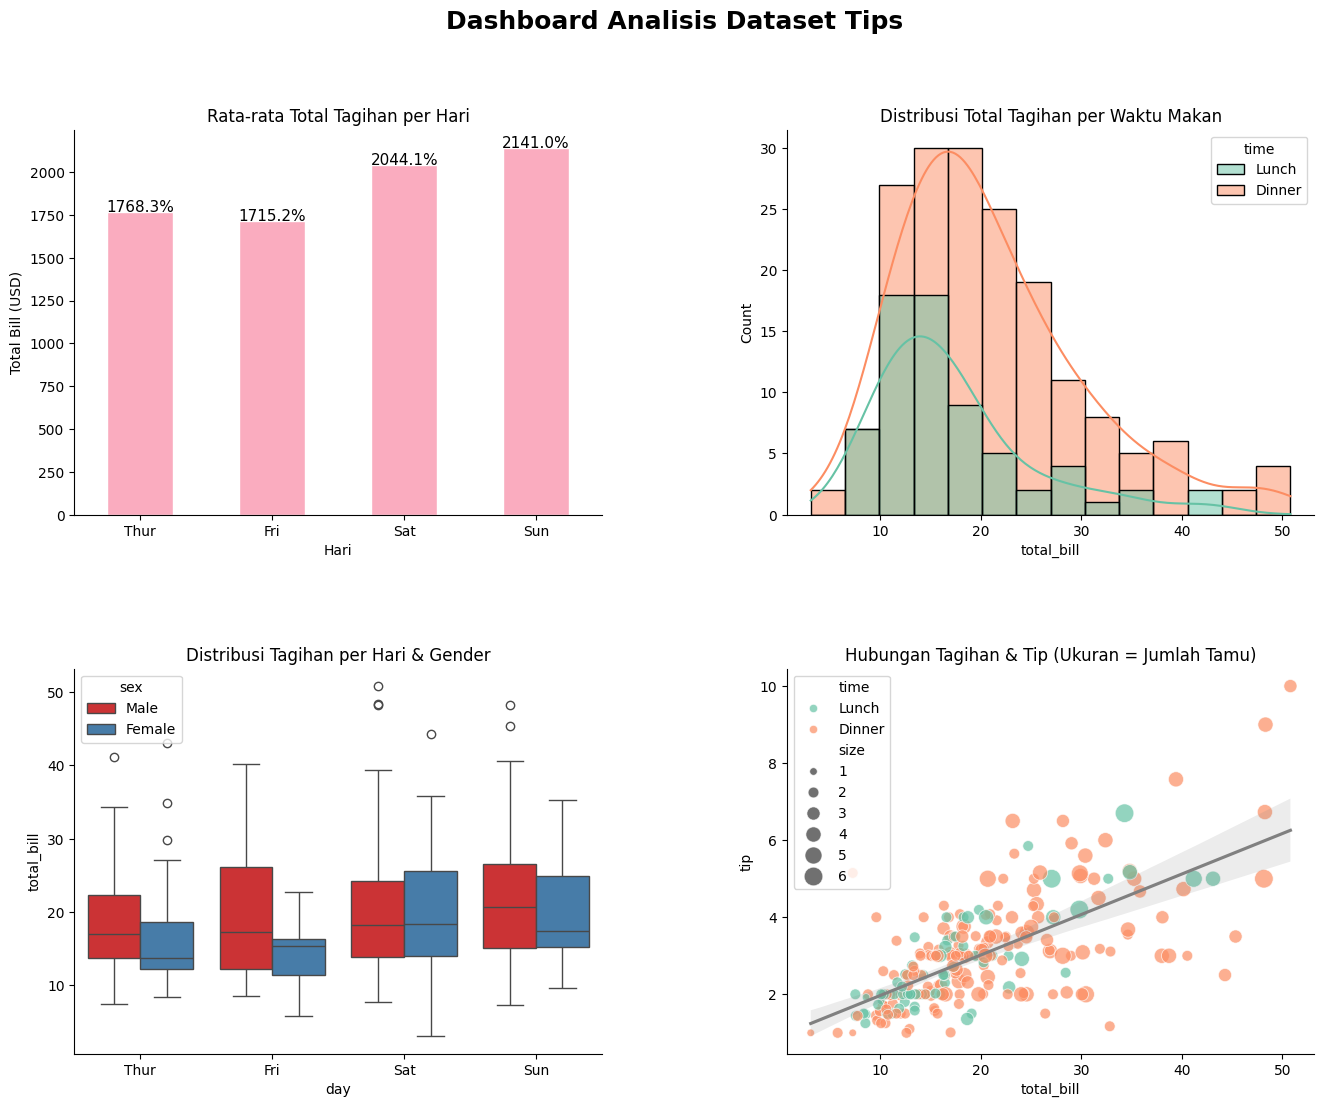

In [16]:
# 2. SETUP FIGURE LAYOUT
fig = plt.figure(figsize=(16,12))
fig.suptitle('Dashboard Analisis Dataset Tips',
             fontsize=18, fontweight='bold',y=0.98)
# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])  # kiri atas
ax2 = fig.add_subplot(gs[0, 1])  # kanan atas
ax3 = fig.add_subplot(gs[1, 0])  # kiri bawah
ax4 = fig.add_subplot(gs[1, 1])  # kanan bawah

# 3. GRAFIK 1 : Bar Chart
#fig, ax1 = plt.subplots()

#avg_by_day = df.groupby('day')['total_bill'].mean() * 100
avg_by_day = df.groupby('day', observed=True)['total_bill'].mean() * 100
avg_by_day.plot(kind='bar', ax=ax1, color='#FAACBF', edgecolor='white')

ax1.set_title('\n\nRata-rata Total Tagihan per Hari')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Total Bill (USD)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)
for i, v in enumerate(avg_by_day.values):
    ax1.text(
        i,
        v + 1,
        f'{v:.1f}%',
        ha='center',
        fontsize=11
    )

# 4. GRAFIK 2 : Histogram + KDE
sns.histplot(data=df, x='total_bill', hue='time', kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan')
ax2.spines[['top','right']].set_visible(False)

# 5. GRAFIK 3: Boxplot
sns.boxplot(data=df, x='day', y='total_bill', hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari & Gender')
ax3.spines[['top','right']].set_visible(False)

# 6. GRAFIK 4: Scatter Plot
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', size='size', sizes=(30,180), palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip', scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)')
ax4.spines[['top','right']].set_visible(False)

# 7. EKSPOR
plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
print('Dashboard tersimpan sebagai dashboard_tips.png')

plt.show()
